In [158]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [159]:
PROJECT_ROOT = Path("/Users/tildeidunsloth/Desktop/Thesis")
DATA_DIR = PROJECT_ROOT / "data/associational_gender_bias"

In [160]:
gender_bias_df_literary_fiction = pd.read_csv(DATA_DIR / "literary_fiction_associational_gender_bias.csv")
gender_bias_df_romance = pd.read_csv(DATA_DIR / "romance_associational_gender_bias.csv")
gender_bias_df_sci_fi = pd.read_csv(DATA_DIR / "sci_fi_associational_gender_bias.csv")

# add a column for genre
gender_bias_df_literary_fiction["genre"] = "Literary Fiction"
gender_bias_df_romance["genre"] = "Romance"
gender_bias_df_sci_fi["genre"] = "Sci-Fi"

# merge the three dataframes into one
gender_bias_df = pd.concat([gender_bias_df_literary_fiction, gender_bias_df_romance, gender_bias_df_sci_fi], ignore_index=True)

### Violin plot

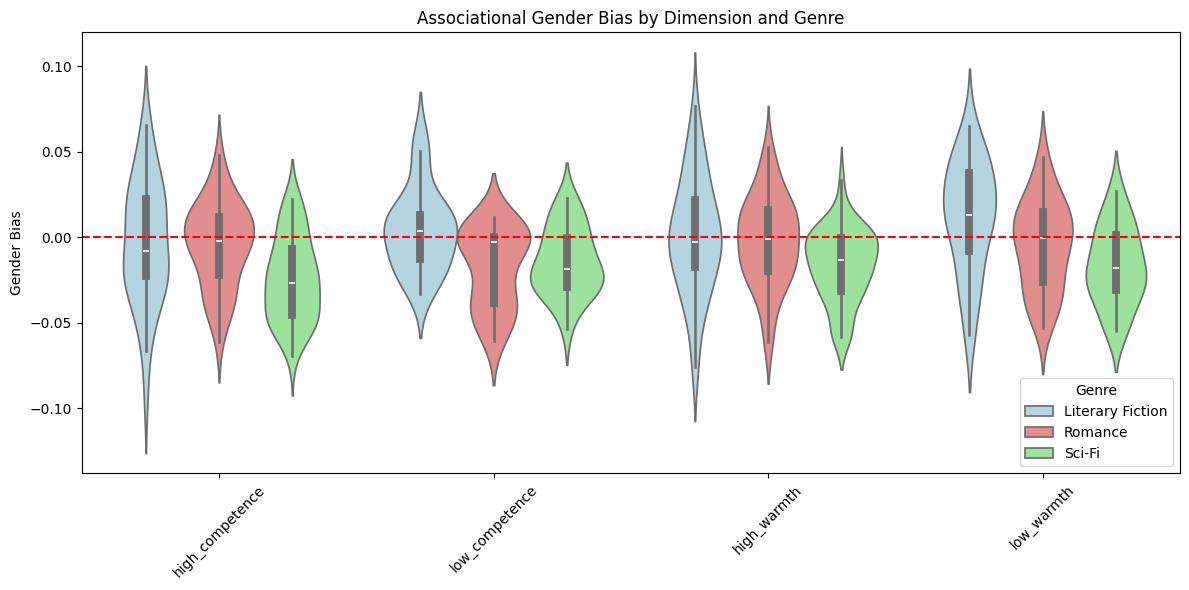

In [161]:
genre_colors = {
    "Literary Fiction": "lightblue", 
    "Romance": "lightcoral",          
    "Sci-Fi": "lightgreen"             
}

plt.figure(figsize=(12, 6))
sns.violinplot(x="dimension", y="gender_bias", hue="genre", data=gender_bias_df, 
               palette=genre_colors, split=False)
plt.title("Associational Gender Bias by Dimension and Genre")
plt.xlabel(None)
plt.ylabel("Gender Bias")
plt.axhline(0, color="red", linestyle="--")
plt.xticks(rotation=45)
plt.legend(title="Genre")
plt.tight_layout()
plt.show()

### Interaction Plot

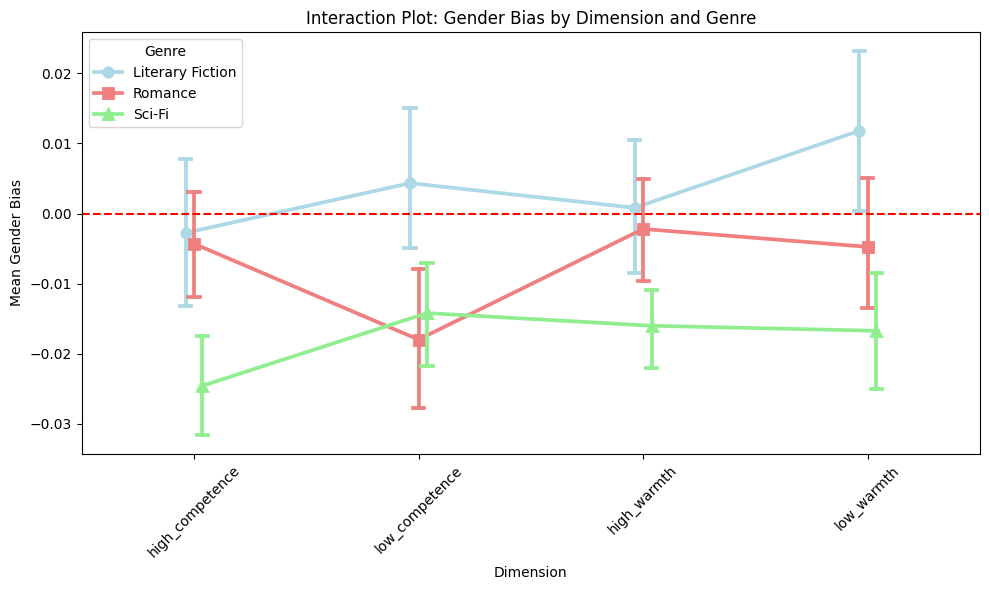

In [162]:
plt.figure(figsize=(10, 6))
sns.pointplot(
    x="dimension", 
    y="gender_bias", 
    hue="genre",
    data=gender_bias_df,
    palette=genre_colors,
    markers=["o", "s", "^", "D"],  # adjust based on number of genres
    linestyles="-",
    dodge=True,  # slightly separates points to avoid overlap
    capsize=0.05,  # adds caps to error bars
    errorbar="ci"  # 95% confidence interval, can also use "sd"
)
plt.axhline(0, color="red", linestyle="--")
plt.title("Interaction Plot: Gender Bias by Dimension and Genre")
plt.xlabel("Dimension")
plt.ylabel("Mean Gender Bias")
plt.legend(title="Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Bar plot

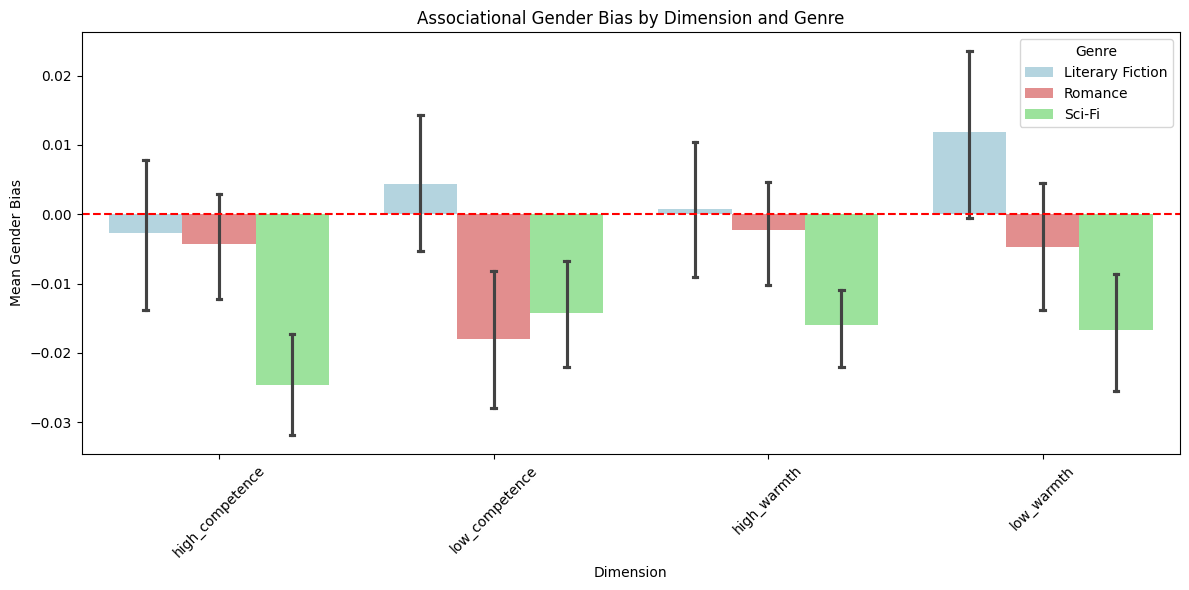

In [163]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x="dimension",
    y="gender_bias",
    hue="genre",
    data=gender_bias_df,
    palette=genre_colors,
    capsize=0.05,  # adds caps to error bars
    errorbar="ci"  # 95% confidence interval
)
plt.axhline(0, color="red", linestyle="--")
plt.title("Associational Gender Bias by Dimension and Genre")
plt.xlabel("Dimension")
plt.ylabel("Mean Gender Bias")
plt.legend(title="Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Heatmap

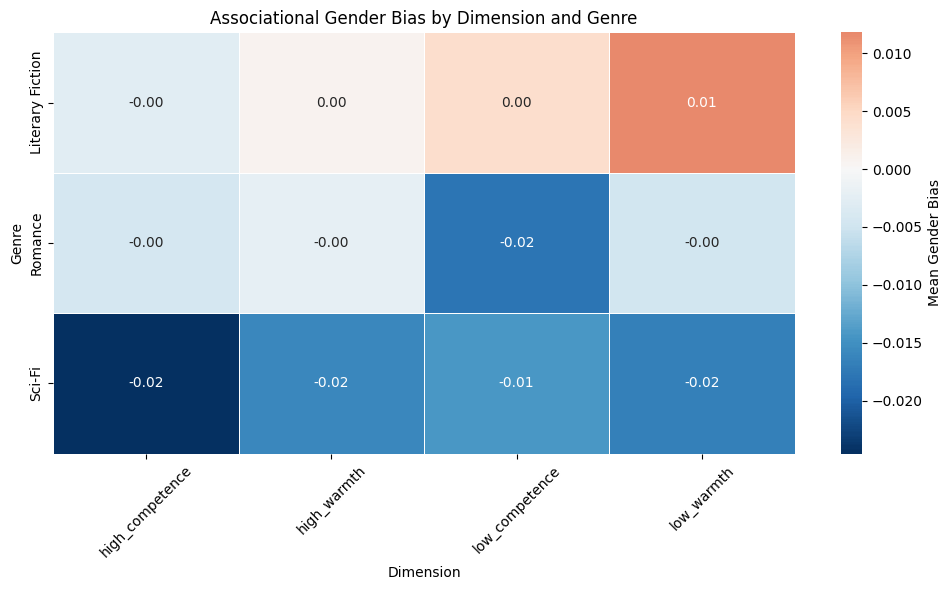

In [164]:
# First create a pivot table of mean gender bias
heatmap_data = gender_bias_df.groupby(["genre", "dimension"])["gender_bias"].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    cmap="RdBu_r",      # diverging colormap: red = male bias, blue = female bias
    center=0,           # centers the colormap at 0
    annot=True,         # shows values in each cell
    fmt=".2f",          # format to 2 decimal places
    linewidths=0.5,     # adds grid lines between cells
    cbar_kws={"label": "Mean Gender Bias"}
)
plt.title("Associational Gender Bias by Dimension and Genre")
plt.xlabel("Dimension")
plt.ylabel("Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Horizontal bar plot

##### Low warmth

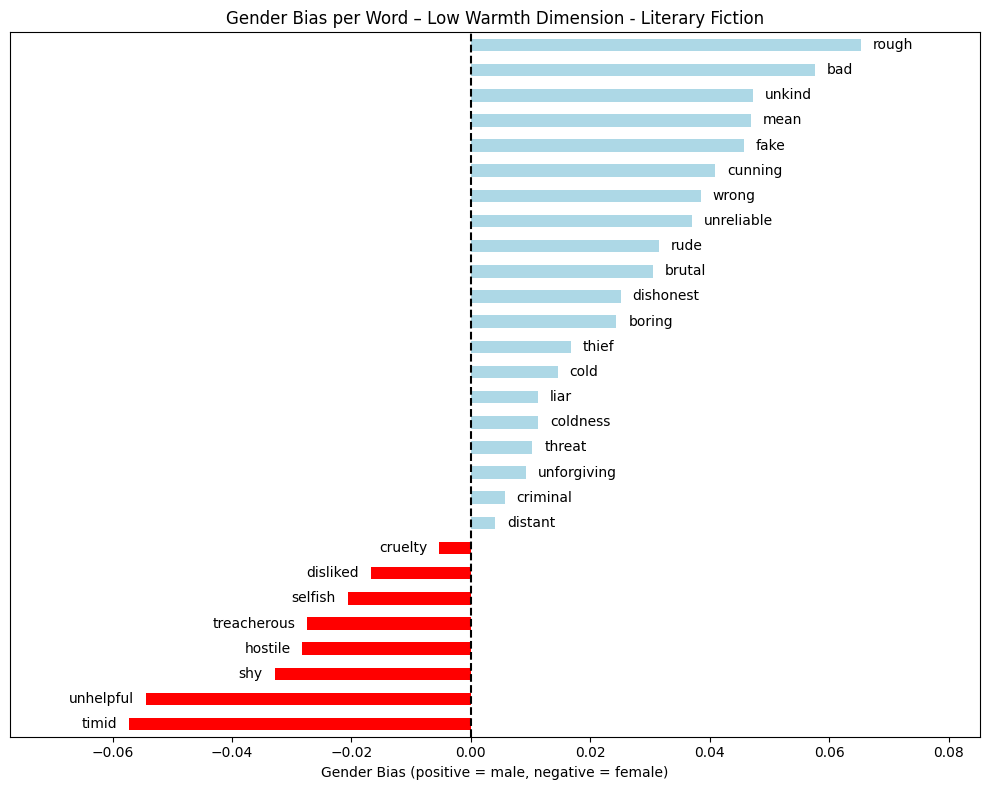

In [165]:
low_warmth_df = gender_bias_df_literary_fiction[gender_bias_df_literary_fiction["dimension"] == "low_warmth"]
word_bias = low_warmth_df.groupby("word")["gender_bias"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["lightblue" if x > 0 else "red" for x in word_bias.values]
word_bias.plot(kind="barh", color=colors, ax=ax)

# Remove y-axis tick labels
ax.set_yticks([])

# Add word labels at the end of each bar
for i, (word, value) in enumerate(word_bias.items()):
    if value > 0:
        ax.text(value + 0.002, i, word, va="center", ha="left", fontsize=10)   # positive: label just beyond right end
    else:
        ax.text(value - 0.002, i, word, va="center", ha="right", fontsize=10)  # negative: label just beyond left end

ax.axvline(0, color="black", linestyle="--")
ax.set_title("Gender Bias per Word – Low Warmth Dimension - Literary Fiction")
ax.set_xlabel("Gender Bias (positive = male, negative = female)")
ax.set_ylabel("")
ax.set_xlim(word_bias.min() - 0.02, word_bias.max() + 0.02)  # add some padding to x-axis limits
plt.tight_layout()
plt.show()

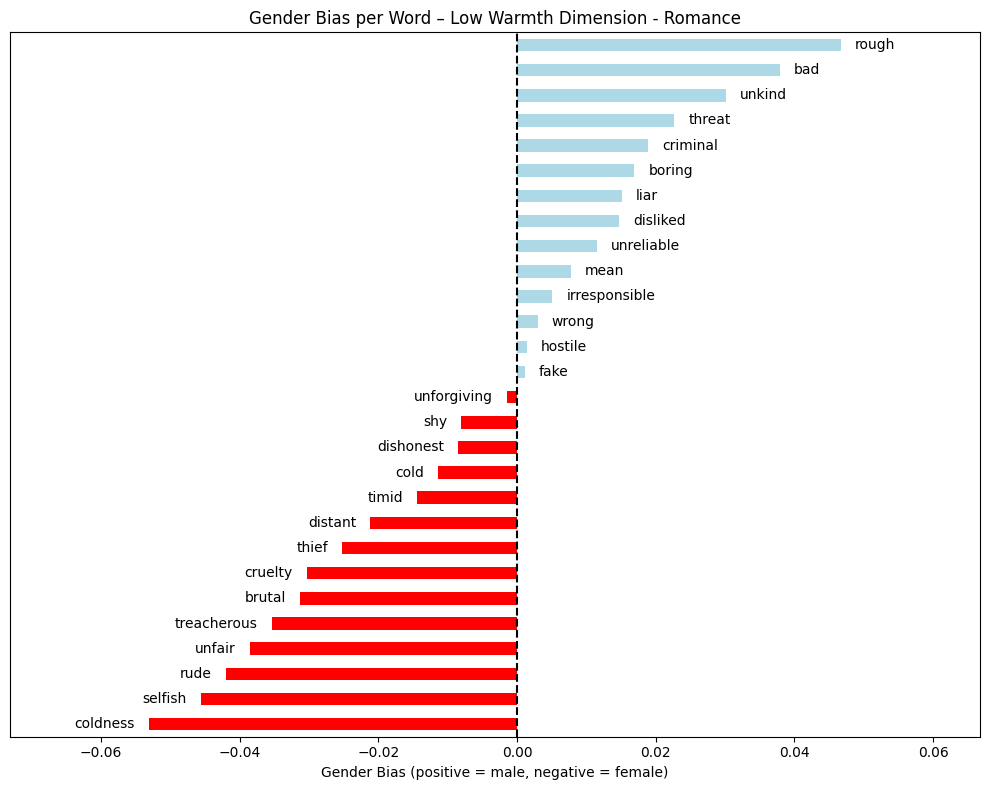

In [166]:
low_warmth_df = gender_bias_df_romance[gender_bias_df_romance["dimension"] == "low_warmth"]
word_bias = low_warmth_df.groupby("word")["gender_bias"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["lightblue" if x > 0 else "red" for x in word_bias.values]
word_bias.plot(kind="barh", color=colors, ax=ax)

# Remove y-axis tick labels
ax.set_yticks([])

# Add word labels at the end of each bar
for i, (word, value) in enumerate(word_bias.items()):
    if value > 0:
        ax.text(value + 0.002, i, word, va="center", ha="left", fontsize=10)   # positive: label just beyond right end
    else:
        ax.text(value - 0.002, i, word, va="center", ha="right", fontsize=10)  # negative: label just beyond left end

ax.axvline(0, color="black", linestyle="--")
ax.set_title("Gender Bias per Word – Low Warmth Dimension - Romance")
ax.set_xlabel("Gender Bias (positive = male, negative = female)")
ax.set_ylabel("")
ax.set_xlim(word_bias.min() - 0.02, word_bias.max() + 0.02)  # add some padding to x-axis limits
plt.tight_layout()
plt.show()

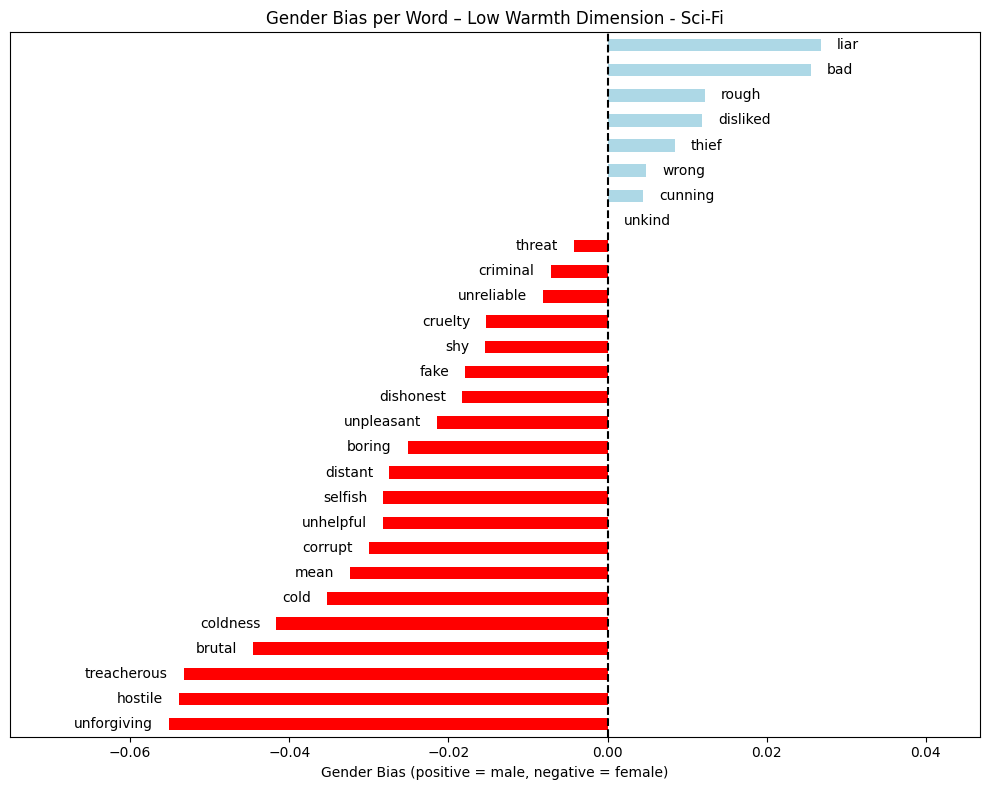

In [167]:
low_warmth_df = gender_bias_df_sci_fi[gender_bias_df_sci_fi["dimension"] == "low_warmth"]
word_bias = low_warmth_df.groupby("word")["gender_bias"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["lightblue" if x > 0 else "red" for x in word_bias.values]
word_bias.plot(kind="barh", color=colors, ax=ax)

# Remove y-axis tick labels
ax.set_yticks([])

# Add word labels at the end of each bar
for i, (word, value) in enumerate(word_bias.items()):
    if value > 0:
        ax.text(value + 0.002, i, word, va="center", ha="left", fontsize=10)   # positive: label just beyond right end
    else:
        ax.text(value - 0.002, i, word, va="center", ha="right", fontsize=10)  # negative: label just beyond left end

ax.axvline(0, color="black", linestyle="--")
ax.set_title("Gender Bias per Word – Low Warmth Dimension - Sci-Fi")
ax.set_xlabel("Gender Bias (positive = male, negative = female)")
ax.set_ylabel("")
ax.set_xlim(word_bias.min() - 0.02, word_bias.max() + 0.02)  # add some padding to x-axis limits
plt.tight_layout()
plt.show()

##### High warmth

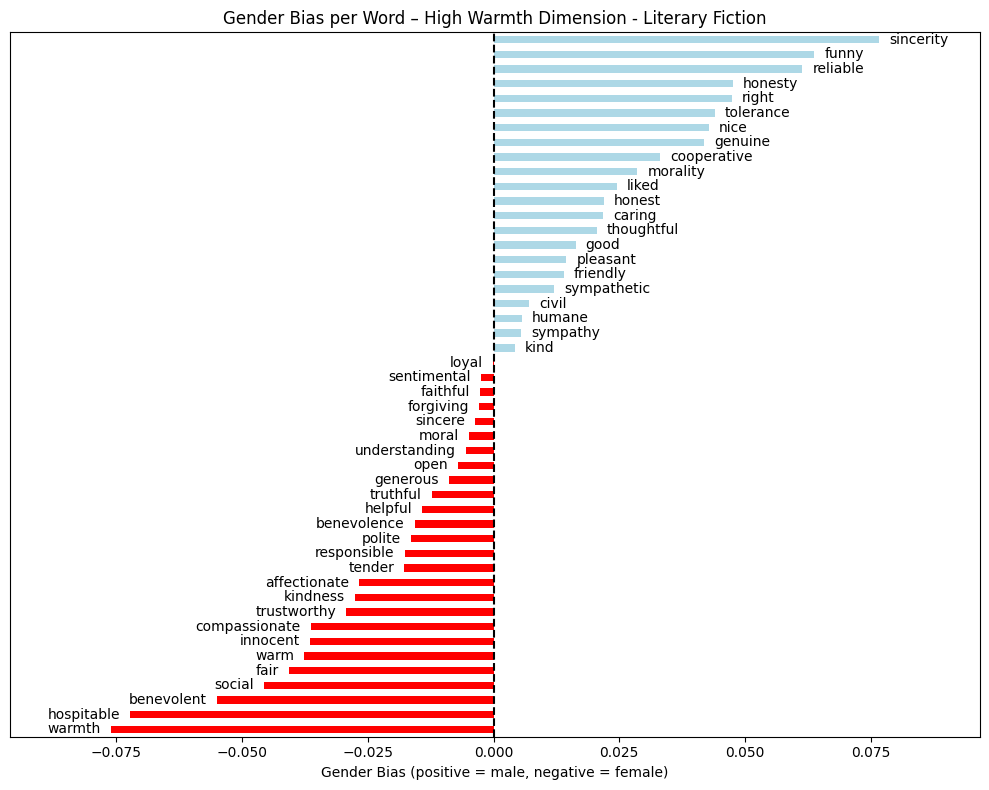

In [168]:
high_warmth_df = gender_bias_df_literary_fiction[gender_bias_df_literary_fiction["dimension"] == "high_warmth"]
word_bias = high_warmth_df.groupby("word")["gender_bias"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["lightblue" if x > 0 else "red" for x in word_bias.values]
word_bias.plot(kind="barh", color=colors, ax=ax)

# Remove y-axis tick labels
ax.set_yticks([])

# Add word labels at the end of each bar
for i, (word, value) in enumerate(word_bias.items()):
    if value > 0:
        ax.text(value + 0.002, i, word, va="center", ha="left", fontsize=10)   # positive: label just beyond right end
    else:
        ax.text(value - 0.002, i, word, va="center", ha="right", fontsize=10)  # negative: label just beyond left end

ax.axvline(0, color="black", linestyle="--")
ax.set_title("Gender Bias per Word – High Warmth Dimension - Literary Fiction")
ax.set_xlabel("Gender Bias (positive = male, negative = female)")
ax.set_ylabel("")
ax.set_xlim(word_bias.min() - 0.02, word_bias.max() + 0.02)  # add some padding to x-axis limits
plt.tight_layout()
plt.show()

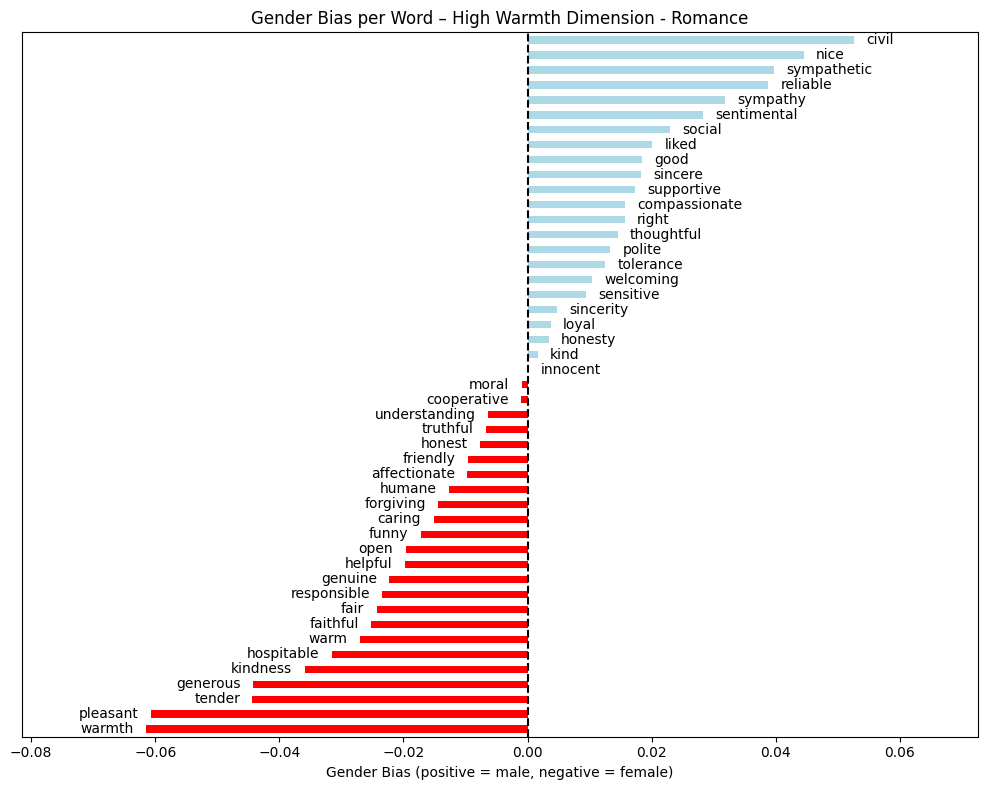

In [169]:
high_warmth_df = gender_bias_df_romance[gender_bias_df_romance["dimension"] == "high_warmth"]
word_bias = high_warmth_df.groupby("word")["gender_bias"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["lightblue" if x > 0 else "red" for x in word_bias.values]
word_bias.plot(kind="barh", color=colors, ax=ax)

# Remove y-axis tick labels
ax.set_yticks([])

# Add word labels at the end of each bar
for i, (word, value) in enumerate(word_bias.items()):
    if value > 0:
        ax.text(value + 0.002, i, word, va="center", ha="left", fontsize=10)   # positive: label just beyond right end
    else:
        ax.text(value - 0.002, i, word, va="center", ha="right", fontsize=10)  # negative: label just beyond left end

ax.axvline(0, color="black", linestyle="--")
ax.set_title("Gender Bias per Word – High Warmth Dimension - Romance")
ax.set_xlabel("Gender Bias (positive = male, negative = female)")
ax.set_ylabel("")
ax.set_xlim(word_bias.min() - 0.02, word_bias.max() + 0.02)  # add some padding to x-axis limits
plt.tight_layout()
plt.show()

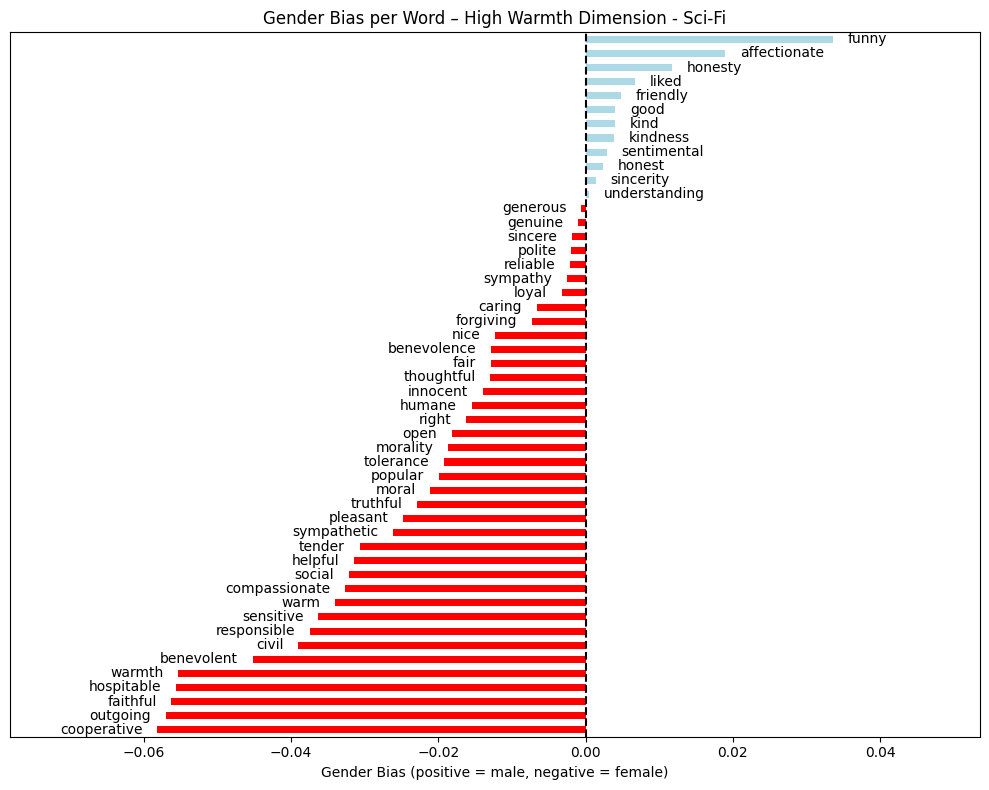

In [170]:
high_warmth_df = gender_bias_df_sci_fi[gender_bias_df_sci_fi["dimension"] == "high_warmth"]
word_bias = high_warmth_df.groupby("word")["gender_bias"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["lightblue" if x > 0 else "red" for x in word_bias.values]
word_bias.plot(kind="barh", color=colors, ax=ax)

# Remove y-axis tick labels
ax.set_yticks([])

# Add word labels at the end of each bar
for i, (word, value) in enumerate(word_bias.items()):
    if value > 0:
        ax.text(value + 0.002, i, word, va="center", ha="left", fontsize=10)   # positive: label just beyond right end
    else:
        ax.text(value - 0.002, i, word, va="center", ha="right", fontsize=10)  # negative: label just beyond left end

ax.axvline(0, color="black", linestyle="--")
ax.set_title("Gender Bias per Word – High Warmth Dimension - Sci-Fi")
ax.set_xlabel("Gender Bias (positive = male, negative = female)")
ax.set_ylabel("")
ax.set_xlim(word_bias.min() - 0.02, word_bias.max() + 0.02)  # add some padding to x-axis limits
plt.tight_layout()
plt.show()

##### Low competence

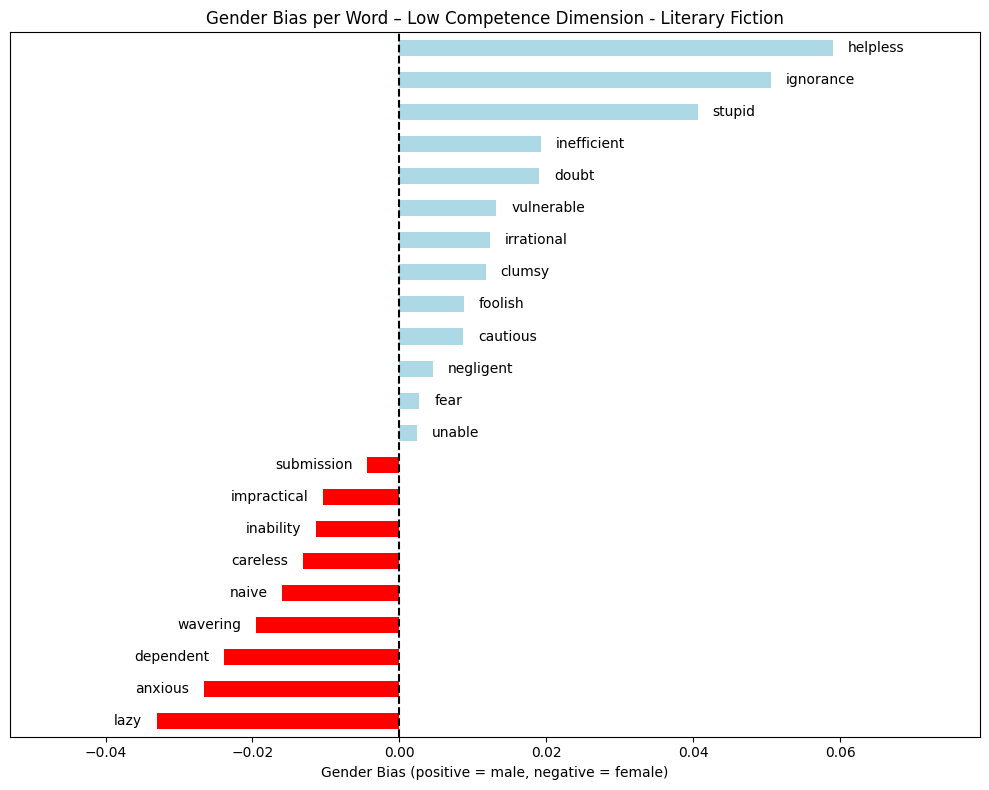

In [171]:
low_competence_df = gender_bias_df_literary_fiction[gender_bias_df_literary_fiction["dimension"] == "low_competence"]
word_bias = low_competence_df.groupby("word")["gender_bias"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["lightblue" if x > 0 else "red" for x in word_bias.values]
word_bias.plot(kind="barh", color=colors, ax=ax)

# Remove y-axis tick labels
ax.set_yticks([])

# Add word labels at the end of each bar
for i, (word, value) in enumerate(word_bias.items()):
    if value > 0:
        ax.text(value + 0.002, i, word, va="center", ha="left", fontsize=10)   # positive: label just beyond right end
    else:
        ax.text(value - 0.002, i, word, va="center", ha="right", fontsize=10)  # negative: label just beyond left end

ax.axvline(0, color="black", linestyle="--")
ax.set_title("Gender Bias per Word – Low Competence Dimension - Literary Fiction")
ax.set_xlabel("Gender Bias (positive = male, negative = female)")
ax.set_ylabel("")
ax.set_xlim(word_bias.min() - 0.02, word_bias.max() + 0.02)  # add some padding to x-axis limits
plt.tight_layout()
plt.show()

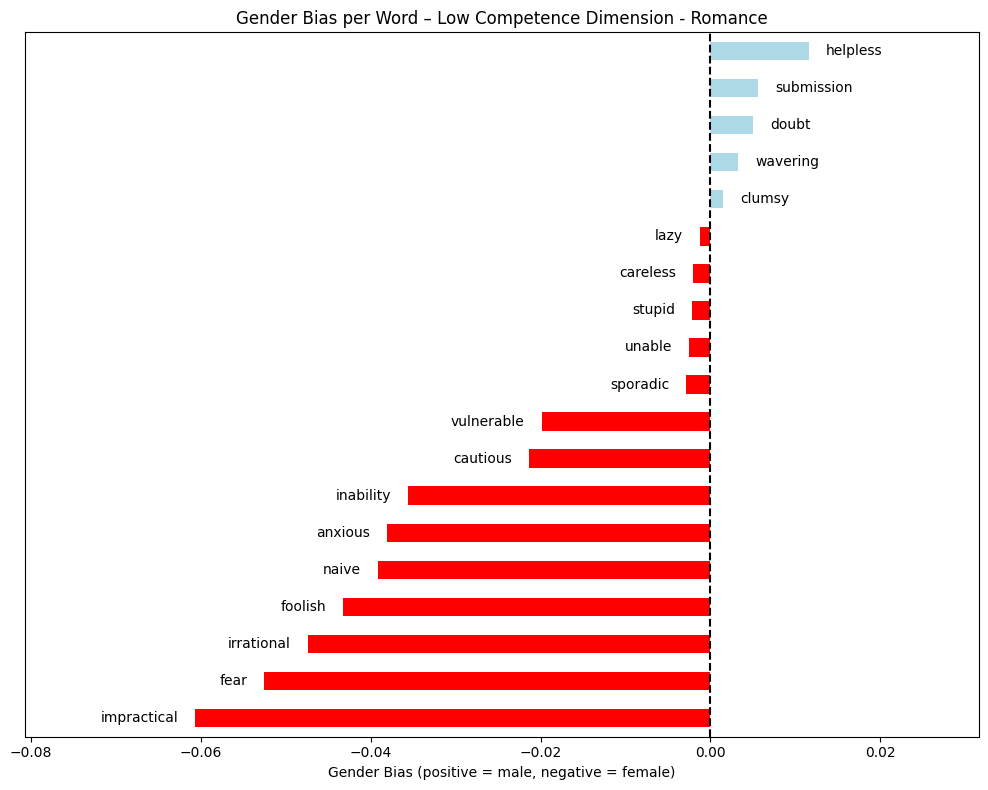

In [172]:
low_competence_df = gender_bias_df_romance[gender_bias_df_romance["dimension"] == "low_competence"]
word_bias = low_competence_df.groupby("word")["gender_bias"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["lightblue" if x > 0 else "red" for x in word_bias.values]
word_bias.plot(kind="barh", color=colors, ax=ax)

# Remove y-axis tick labels
ax.set_yticks([])

# Add word labels at the end of each bar
for i, (word, value) in enumerate(word_bias.items()):
    if value > 0:
        ax.text(value + 0.002, i, word, va="center", ha="left", fontsize=10)   # positive: label just beyond right end
    else:
        ax.text(value - 0.002, i, word, va="center", ha="right", fontsize=10)  # negative: label just beyond left end

ax.axvline(0, color="black", linestyle="--")
ax.set_title("Gender Bias per Word – Low Competence Dimension - Romance")
ax.set_xlabel("Gender Bias (positive = male, negative = female)")
ax.set_ylabel("")
ax.set_xlim(word_bias.min() - 0.02, word_bias.max() + 0.02)  # add some padding to x-axis limits
plt.tight_layout()
plt.show()

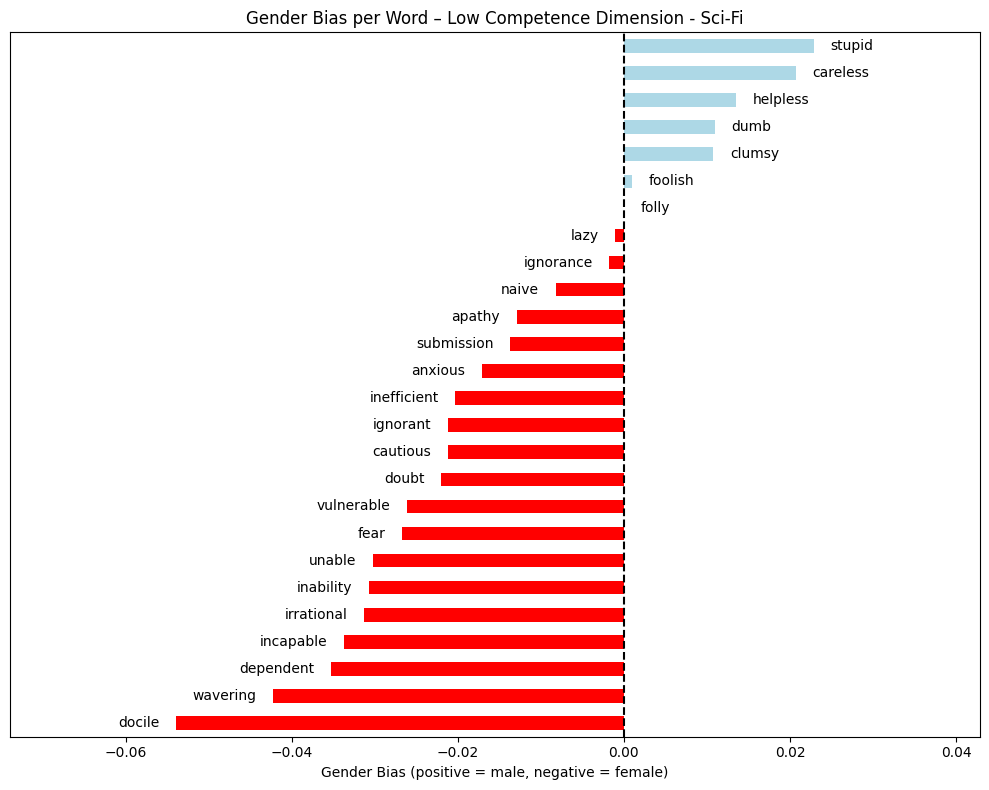

In [173]:
low_competence_df = gender_bias_df_sci_fi[gender_bias_df_sci_fi["dimension"] == "low_competence"]
word_bias = low_competence_df.groupby("word")["gender_bias"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["lightblue" if x > 0 else "red" for x in word_bias.values]
word_bias.plot(kind="barh", color=colors, ax=ax)

# Remove y-axis tick labels
ax.set_yticks([])

# Add word labels at the end of each bar
for i, (word, value) in enumerate(word_bias.items()):
    if value > 0:
        ax.text(value + 0.002, i, word, va="center", ha="left", fontsize=10)   # positive: label just beyond right end
    else:
        ax.text(value - 0.002, i, word, va="center", ha="right", fontsize=10)  # negative: label just beyond left end

ax.axvline(0, color="black", linestyle="--")
ax.set_title("Gender Bias per Word – Low Competence Dimension - Sci-Fi")
ax.set_xlabel("Gender Bias (positive = male, negative = female)")
ax.set_ylabel("")
ax.set_xlim(word_bias.min() - 0.02, word_bias.max() + 0.02)  # add some padding to x-axis limits
plt.tight_layout()
plt.show()

##### High competence

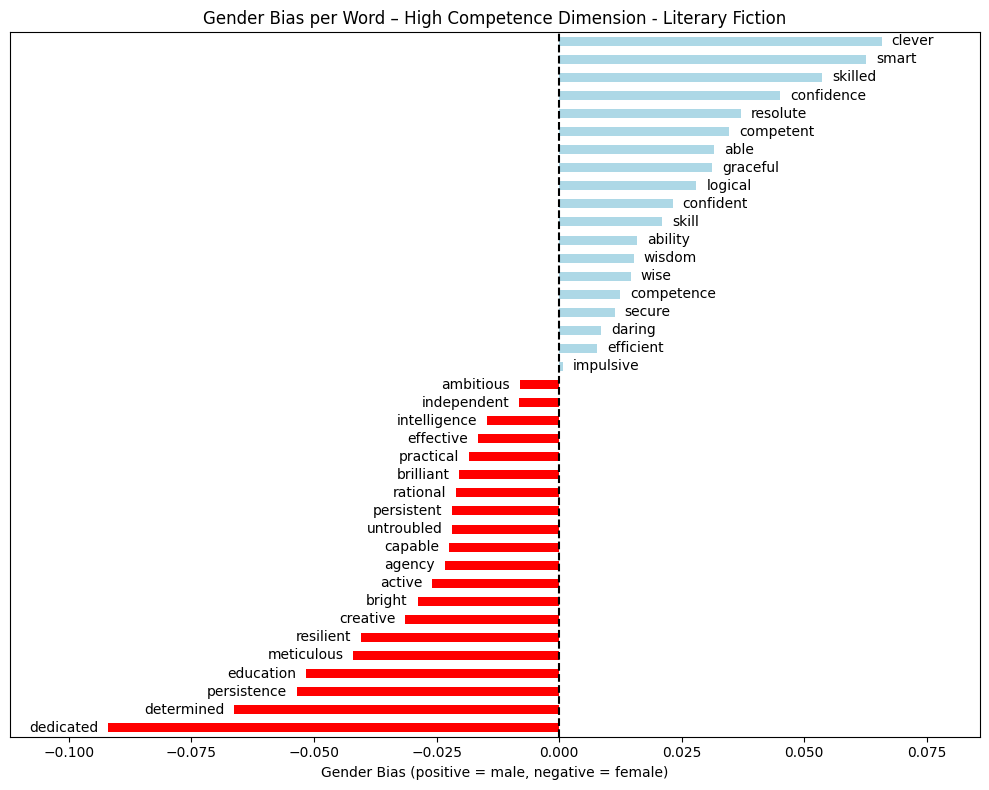

In [174]:
high_competence_df = gender_bias_df_literary_fiction[gender_bias_df_literary_fiction["dimension"] == "high_competence"]
word_bias = high_competence_df.groupby("word")["gender_bias"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["lightblue" if x > 0 else "red" for x in word_bias.values]
word_bias.plot(kind="barh", color=colors, ax=ax)

# Remove y-axis tick labels
ax.set_yticks([])

# Add word labels at the end of each bar
for i, (word, value) in enumerate(word_bias.items()):
    if value > 0:
        ax.text(value + 0.002, i, word, va="center", ha="left", fontsize=10)   # positive: label just beyond right end
    else:
        ax.text(value - 0.002, i, word, va="center", ha="right", fontsize=10)  # negative: label just beyond left end

ax.axvline(0, color="black", linestyle="--")
ax.set_title("Gender Bias per Word – High Competence Dimension - Literary Fiction")
ax.set_xlabel("Gender Bias (positive = male, negative = female)")
ax.set_ylabel("")
ax.set_xlim(word_bias.min() - 0.02, word_bias.max() + 0.02)  # add some padding to x-axis limits
plt.tight_layout()
plt.show()

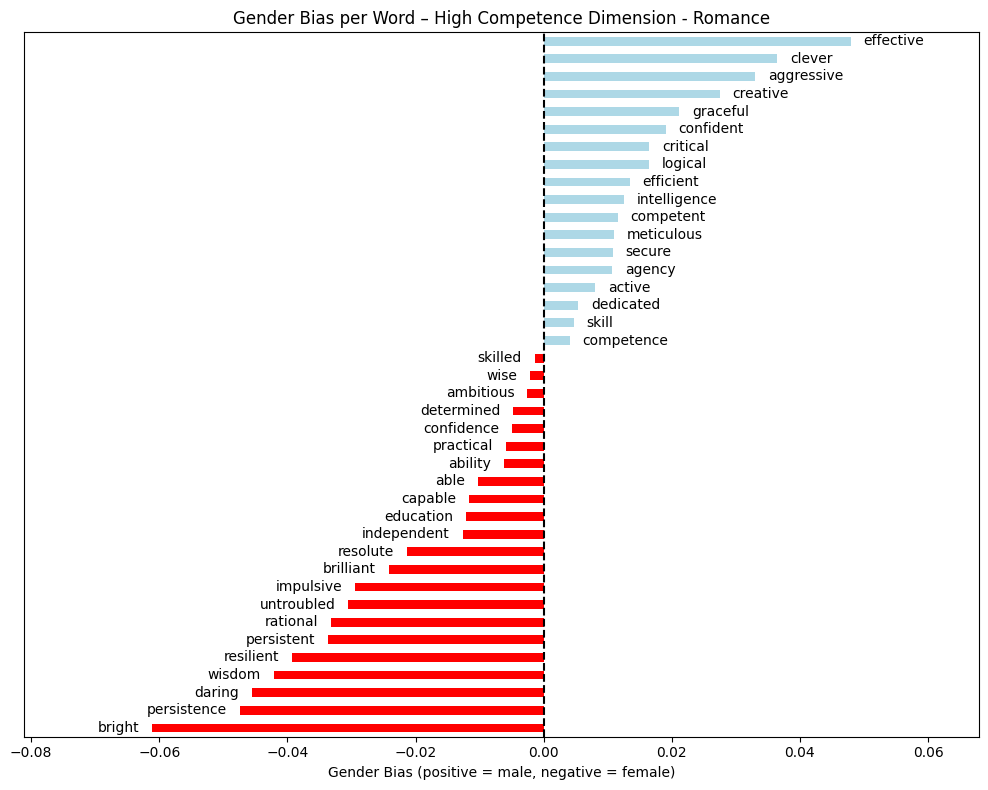

In [175]:
high_competence_df = gender_bias_df_romance[gender_bias_df_romance["dimension"] == "high_competence"]
word_bias = high_competence_df.groupby("word")["gender_bias"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["lightblue" if x > 0 else "red" for x in word_bias.values]
word_bias.plot(kind="barh", color=colors, ax=ax)

# Remove y-axis tick labels
ax.set_yticks([])

# Add word labels at the end of each bar
for i, (word, value) in enumerate(word_bias.items()):
    if value > 0:
        ax.text(value + 0.002, i, word, va="center", ha="left", fontsize=10)   # positive: label just beyond right end
    else:
        ax.text(value - 0.002, i, word, va="center", ha="right", fontsize=10)  # negative: label just beyond left end

ax.axvline(0, color="black", linestyle="--")
ax.set_title("Gender Bias per Word – High Competence Dimension - Romance")
ax.set_xlabel("Gender Bias (positive = male, negative = female)")
ax.set_ylabel("")
ax.set_xlim(word_bias.min() - 0.02, word_bias.max() + 0.02)  # add some padding to x-axis limits
plt.tight_layout()
plt.show()

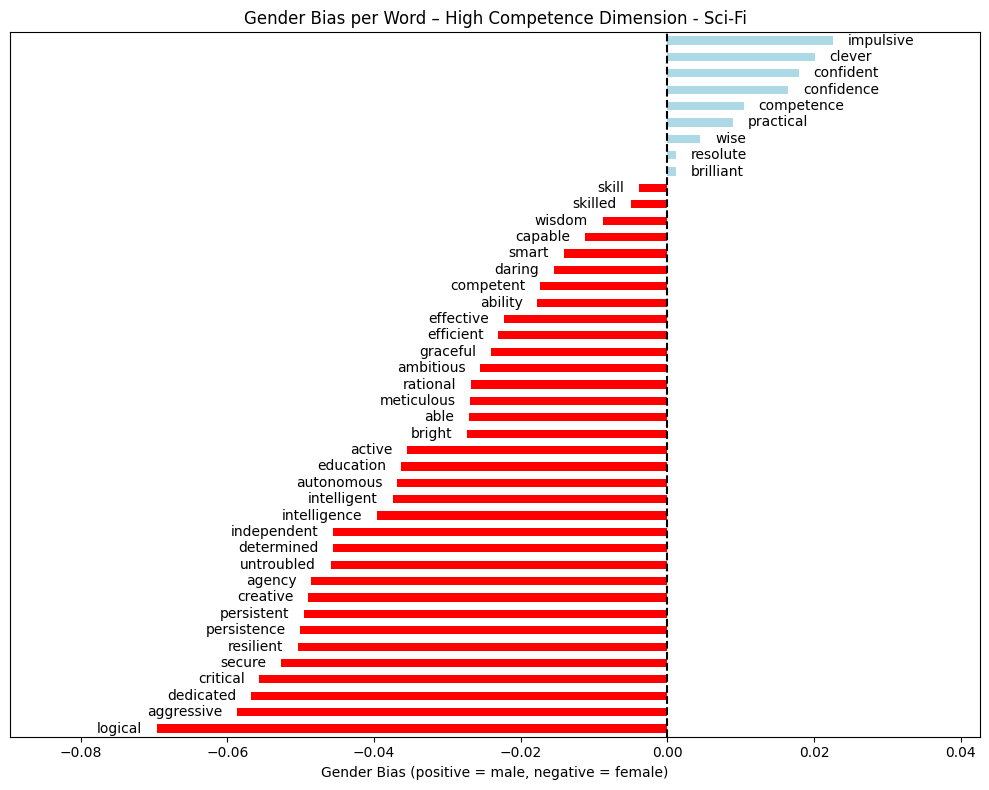

In [176]:
high_competence_df = gender_bias_df_sci_fi[gender_bias_df_sci_fi["dimension"] == "high_competence"]
word_bias = high_competence_df.groupby("word")["gender_bias"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["lightblue" if x > 0 else "red" for x in word_bias.values]
word_bias.plot(kind="barh", color=colors, ax=ax)

# Remove y-axis tick labels
ax.set_yticks([])

# Add word labels at the end of each bar
for i, (word, value) in enumerate(word_bias.items()):
    if value > 0:
        ax.text(value + 0.002, i, word, va="center", ha="left", fontsize=10)   # positive: label just beyond right end
    else:
        ax.text(value - 0.002, i, word, va="center", ha="right", fontsize=10)  # negative: label just beyond left end

ax.axvline(0, color="black", linestyle="--")
ax.set_title("Gender Bias per Word – High Competence Dimension - Sci-Fi")
ax.set_xlabel("Gender Bias (positive = male, negative = female)")
ax.set_ylabel("")
ax.set_xlim(word_bias.min() - 0.02, word_bias.max() + 0.02)  # add some padding to x-axis limits
plt.tight_layout()
plt.show()